In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
data = pd.read_csv('data/train.csv')
data.shape


(72983, 34)

In [3]:
from tqdm import tqdm

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  str    
 3   Auction                            72983 non-null  str    
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  str    
 7   Model                              72983 non-null  str    
 8   Trim                               70623 non-null  str    
 9   SubModel                           72975 non-null  str    
 10  Color                              72975 non-null  str    
 11  Transmission                       72974 non-null  str    
 12  W

In [5]:
data.isna().sum().sort_values(ascending=False)

PRIMEUNIT                            69564
AUCGUART                             69564
WheelType                             3174
WheelTypeID                           3169
Trim                                  2360
MMRCurrentAuctionAveragePrice          315
MMRCurrentRetailCleanPrice             315
MMRCurrentRetailAveragePrice           315
MMRCurrentAuctionCleanPrice            315
MMRAcquisitionAuctionAveragePrice       18
MMRAcquisitionAuctionCleanPrice         18
MMRAcquisitionRetailAveragePrice        18
MMRAcquisitonRetailCleanPrice           18
Transmission                             9
SubModel                                 8
Color                                    8
Nationality                              5
Size                                     5
TopThreeAmericanName                     5
BYRNO                                    0
VNZIP1                                   0
VNST                                     0
VehBCost                                 0
IsOnlineSal

In [6]:
data[['AUCGUART', 'PRIMEUNIT']].value_counts()

AUCGUART  PRIMEUNIT
GREEN     NO           3278
RED       NO             79
GREEN     YES            62
Name: count, dtype: int64

In [7]:
data = data.drop(columns=['PRIMEUNIT', 'AUCGUART'])
data.shape

(72983, 32)

In [8]:
data.PurchDate.dtype

<StringDtype(storage='python', na_value=nan)>

In [9]:
data.PurchDate = pd.to_datetime(data.PurchDate)

In [10]:
data.PurchDate.head()

0   2009-12-07
1   2009-12-07
2   2009-12-07
3   2009-12-07
4   2009-12-07
Name: PurchDate, dtype: datetime64[us]

In [11]:
def split_by_three_date(data : pd.DataFrame, date_col : str):
    df = data.copy()
    l = len(data)
    df = df.sort_values(date_col)
    
    train_end = l // 3
    val_end = (2 * l) // 3

    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]

    return train, val, test

train, val, test = split_by_three_date(data, 'PurchDate')
print(len(train), len(val), len(test))

24327 24328 24328


# Preprocessing

In [12]:
train.info()

<class 'pandas.DataFrame'>
Index: 24327 entries, 32367 to 15838
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   RefId                              24327 non-null  int64         
 1   IsBadBuy                           24327 non-null  int64         
 2   PurchDate                          24327 non-null  datetime64[us]
 3   Auction                            24327 non-null  str           
 4   VehYear                            24327 non-null  int64         
 5   VehicleAge                         24327 non-null  int64         
 6   Make                               24327 non-null  str           
 7   Model                              24327 non-null  str           
 8   Trim                               23600 non-null  str           
 9   SubModel                           24319 non-null  str           
 10  Color                              24319 non-n

In [13]:
train.head(5)

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
32367,32389,0,2009-01-05,MANHEIM,2007,2,CHRYSLER,PACIFICA FWD 3.8L V6,Bas,4D SPORT,BLUE,AUTO,2.0,Covers,78541,AMERICAN,CROSSOVER,CHRYSLER,7261.0,8857.0,8342.0,10066.0,8709.0,10331.0,9906.0,11657.0,3453,80022,CO,6770.0,0,1389
32384,32406,0,2009-01-05,MANHEIM,2005,4,FORD,FREESTAR FWD V6 3.9L,SES,4D PASSENGER 3.9L SES,SILVER,AUTO,1.0,Alloy,37676,AMERICAN,VAN,FORD,4409.0,5734.0,5262.0,6693.0,4908.0,5971.0,5801.0,6949.0,22916,80022,CO,6160.0,0,941
32385,32407,0,2009-01-05,MANHEIM,2004,5,DODGE,STRATUS 4C 2.4L I4 M,SE,4D SEDAN SE,SILVER,AUTO,2.0,Covers,71680,AMERICAN,MEDIUM,CHRYSLER,3098.0,4061.0,3846.0,4886.0,3397.0,4272.0,4169.0,5114.0,3453,80022,CO,4250.0,0,1155
32386,32408,0,2009-01-05,MANHEIM,2006,3,CHEVROLET,TRAILBLAZER EXT 4WD,LS,4D SUV 4.2L,WHITE,AUTO,1.0,Alloy,69456,AMERICAN,MEDIUM SUV,GM,8530.0,9883.0,9712.0,11174.0,9202.0,10794.0,10438.0,12158.0,22916,80022,CO,8180.0,0,1703
32387,32409,0,2009-01-05,MANHEIM,2004,5,FORD,TAURUS 3.0L V6 EFI,SES,4D SEDAN SES DURATEC,GOLD,AUTO,1.0,Alloy,66530,AMERICAN,MEDIUM,FORD,3094.0,4230.0,3842.0,5068.0,3369.0,4492.0,4139.0,5351.0,22916,80022,CO,4900.0,0,825


In [14]:
num_features = train.select_dtypes(include="number").columns.tolist()
date_features = ['PurchDate']
cat_features = list(set(train.columns) - set(num_features) - set(date_features))
cat_features

['Trim',
 'Transmission',
 'TopThreeAmericanName',
 'SubModel',
 'Size',
 'Model',
 'Nationality',
 'Color',
 'WheelType',
 'Auction',
 'VNST',
 'Make']

In [15]:
for col in num_features:
    print(col, train[col].nunique(dropna=False))

RefId 24327
IsBadBuy 2
VehYear 8
VehicleAge 8
WheelTypeID 4
VehOdo 19226
MMRAcquisitionAuctionAveragePrice 6055
MMRAcquisitionAuctionCleanPrice 6362
MMRAcquisitionRetailAveragePrice 6055
MMRAcquisitonRetailCleanPrice 6360
MMRCurrentAuctionAveragePrice 6779
MMRCurrentAuctionCleanPrice 7086
MMRCurrentRetailAveragePrice 6954
MMRCurrentRetailCleanPrice 7275
BYRNO 35
VNZIP1 112
VehBCost 1714
IsOnlineSale 1
WarrantyCost 239


In [16]:
train['BYRNO'].head()

32367     3453
32384    22916
32385     3453
32386    22916
32387    22916
Name: BYRNO, dtype: int64

In [17]:
train['VNZIP1'].head()

32367    80022
32384    80022
32385    80022
32386    80022
32387    80022
Name: VNZIP1, dtype: int64

In [18]:
cat_features += ['BYRNO', 'VNZIP1'] # категориальные, которые были в числовых
num_features.remove('BYRNO')
num_features.remove('VNZIP1')
num_features.remove('IsBadBuy')
target = 'IsBadBuy'
cat_features

['Trim',
 'Transmission',
 'TopThreeAmericanName',
 'SubModel',
 'Size',
 'Model',
 'Nationality',
 'Color',
 'WheelType',
 'Auction',
 'VNST',
 'Make',
 'BYRNO',
 'VNZIP1']

# Date_features

In [19]:

def make_date_features(df, date_col):
    result = pd.DataFrame(index=df.index)
    dt = pd.to_datetime(df[date_col])
    result["PurchYear"] = dt.dt.year
    result["PurchMonth"] = dt.dt.month
    result["PurchDayOfWeek"] = dt.dt.dayofweek
    return result

In [20]:
train_dat = make_date_features(train, 'PurchDate')
val_dat = make_date_features(val, 'PurchDate')
test_dat = make_date_features(test, 'PurchDate')

train = pd.concat([train, train_dat], axis=1)
val = pd.concat([val, val_dat], axis=1)
test = pd.concat([test, test_dat], axis=1)

In [21]:
# num_features += ["PurchYear"]
cat_features += ["PurchMonth", "PurchDayOfWeek"]

## Cat_features

In [22]:
for col in cat_features:
    print(f"{col} \n  uniq: {train[col].nunique()}\n  Nan: {train[col].isna().sum()}")

Trim 
  uniq: 122
  Nan: 727
Transmission 
  uniq: 2
  Nan: 8
TopThreeAmericanName 
  uniq: 4
  Nan: 0
SubModel 
  uniq: 663
  Nan: 8
Size 
  uniq: 12
  Nan: 0
Model 
  uniq: 801
  Nan: 0
Nationality 
  uniq: 4
  Nan: 0
Color 
  uniq: 16
  Nan: 8
WheelType 
  uniq: 3
  Nan: 925
Auction 
  uniq: 3
  Nan: 0
VNST 
  uniq: 29
  Nan: 0
Make 
  uniq: 31
  Nan: 0
BYRNO 
  uniq: 35
  Nan: 0
VNZIP1 
  uniq: 112
  Nan: 0
PurchMonth 
  uniq: 9
  Nan: 0
PurchDayOfWeek 
  uniq: 5
  Nan: 0


модели

Text(0, 0.5, 'Category frequency')

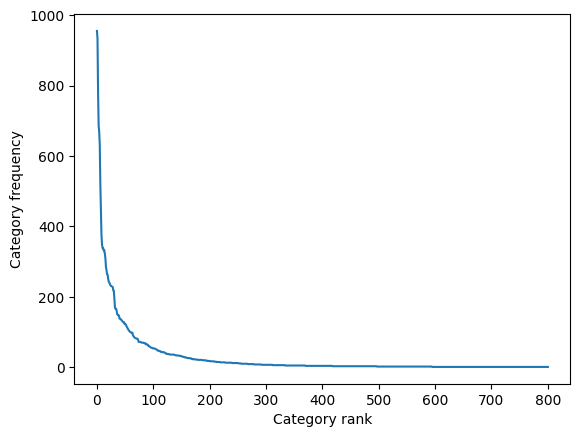

In [23]:
vc = train.Model.value_counts()

sns.lineplot(x=range(len(vc)), y=vc.values)
plt.xlabel("Category rank")
plt.ylabel("Category frequency")

In [24]:
good_values = train['Model'].value_counts().head(50).index

train['Model'] = train['Model'].apply(lambda x: x if x in good_values else "Other")
val['Model'] = val['Model'].apply(lambda x: x if x in good_values else "Other")
test['Model'] = test['Model'].apply(lambda x: x if x in good_values else "Other")

разберемся с сабмоделями

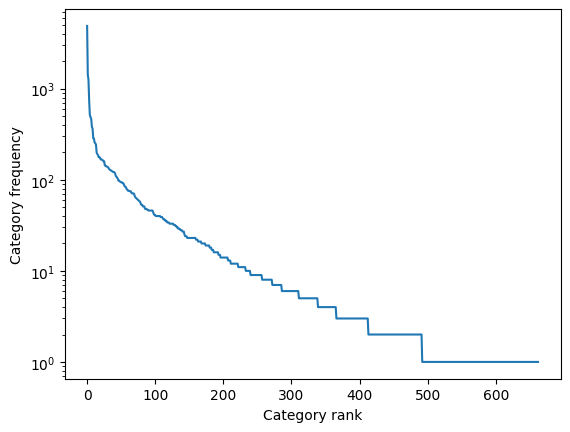

In [25]:
vc = train.SubModel.value_counts()

sns.lineplot(x=range(len(vc)), y=vc.values)
plt.xlabel("Category rank")
plt.ylabel("Category frequency")
plt.yscale("log")

In [26]:
train.SubModel.value_counts()

SubModel
4D SEDAN                            4903
4D SEDAN SE                         1427
4D SEDAN LS                         1259
4D SEDAN SXT FFV                     742
MINIVAN 3.3L                         517
4D SUV 4.2L LS                       488
4D WAGON                             469
4D SEDAN LT                          382
2D COUPE                             366
4D SEDAN LX                          286
4D SPORT                             284
4D SEDAN EX                          257
4D SEDAN LT 3.5L                     252
4D SEDAN CLASSIC                     244
4D SEDAN SEL                         199
PASSENGER EXT 3.5L                   192
WAGON 2.7L                           187
4D SUV 4.2L                          177
4D SEDAN LEVEL 2                     177
4D WAGON LAREDO                      175
4D SEDAN ES                          167
4D SEDAN GT                          167
4D SUV 4.7L SLT                      166
4D SEDAN SE1                         164
4D SUV 

In [27]:
vc = train["SubModel"].value_counts()
good_values = vc[vc >= 5].index

train["SubModel"] = train["SubModel"].apply(lambda x: x if x in good_values else "Other")
val["SubModel"] = val["SubModel"].apply(lambda x: x if x in good_values else "Other")
test["SubModel"] = test["SubModel"].apply(lambda x: x if x in good_values else "Other")

И еще Trim

Text(0, 0.5, 'Category frequency')

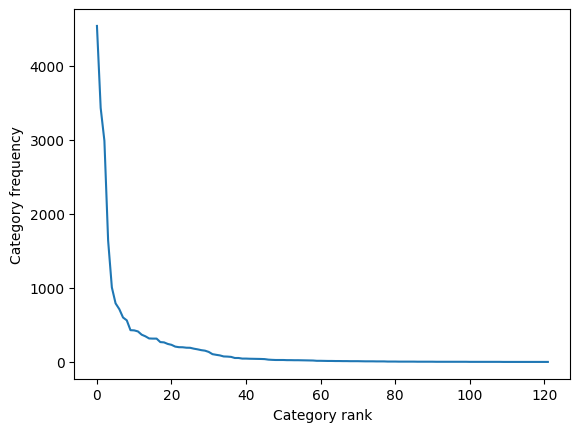

In [28]:
vc = train.Trim.value_counts()

sns.lineplot(x=range(len(vc)), y=vc.values)
plt.xlabel("Category rank")
plt.ylabel("Category frequency")

In [29]:
good_values = train['Trim'].value_counts().head(20).index

train['Trim'] = train['Trim'].apply(lambda x: x if x in good_values else "Other")
val['Trim'] = val['Trim'].apply(lambda x: x if x in good_values else "Other")
test['Trim'] = test['Trim'].apply(lambda x: x if x in good_values else "Other")

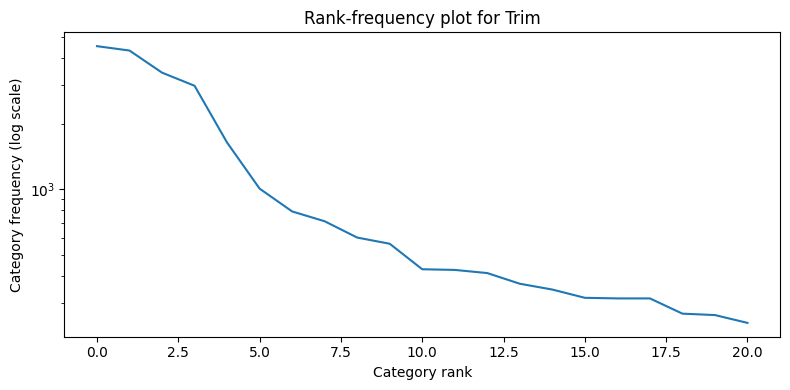

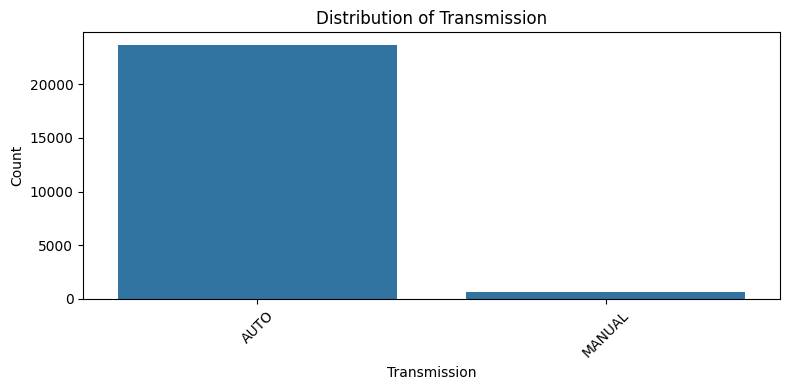

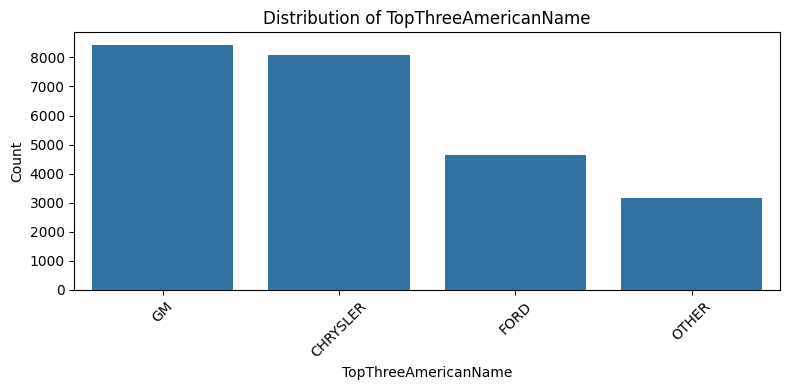

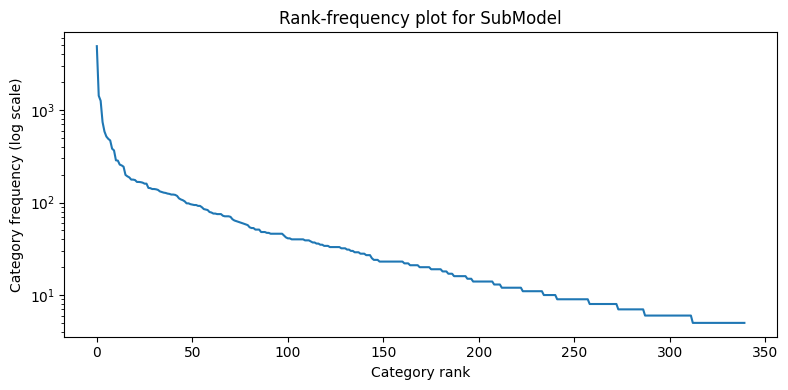

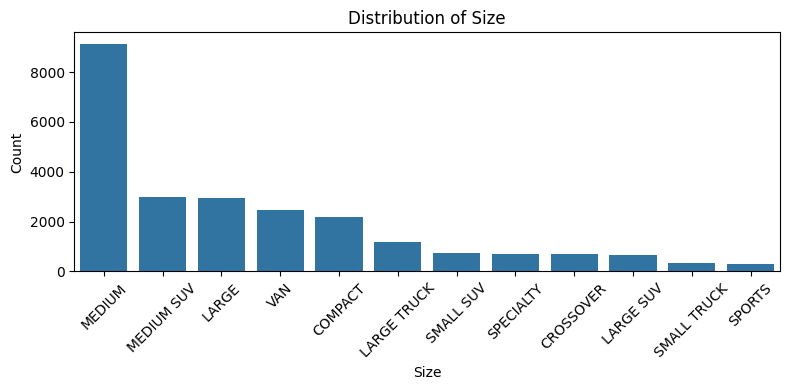

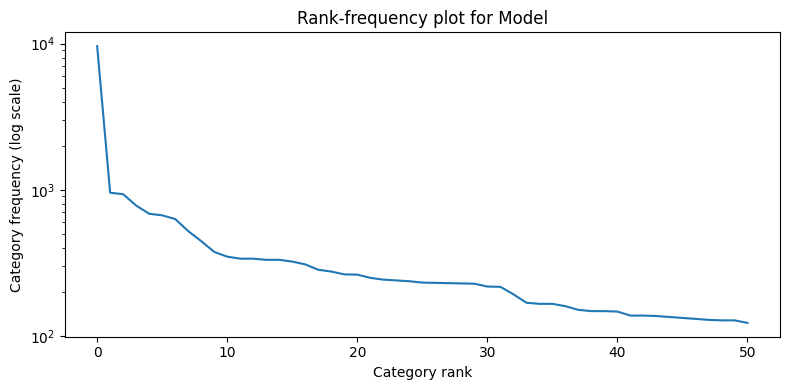

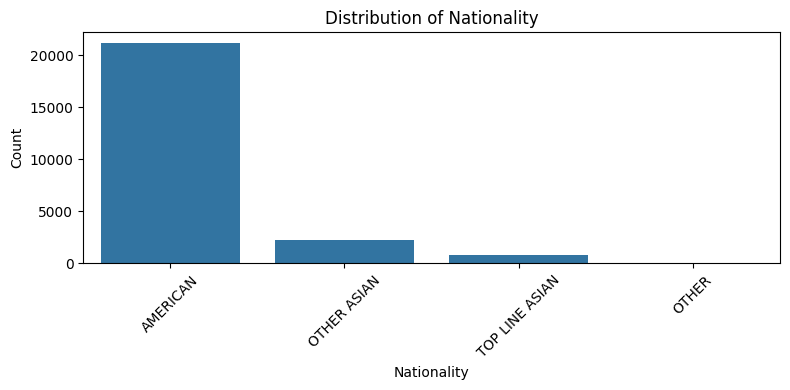

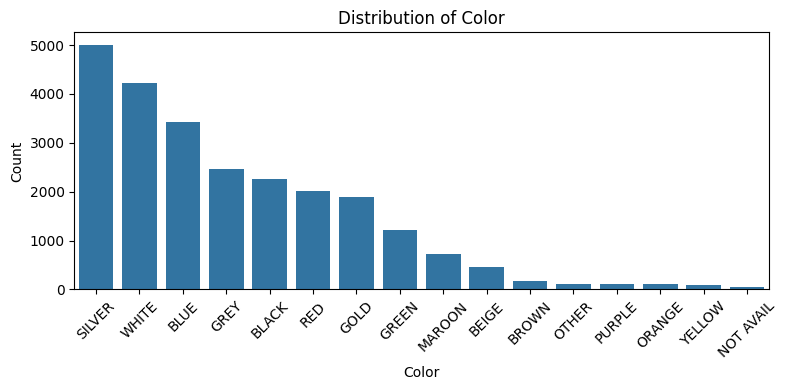

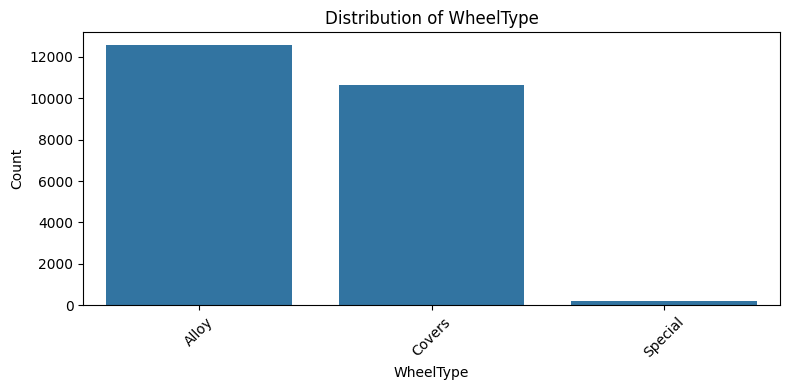

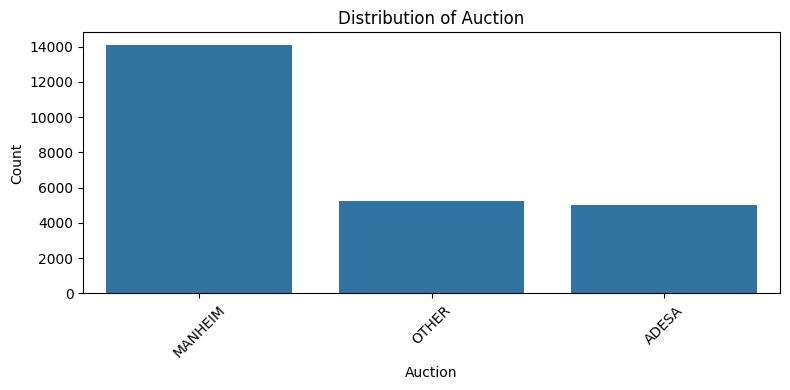

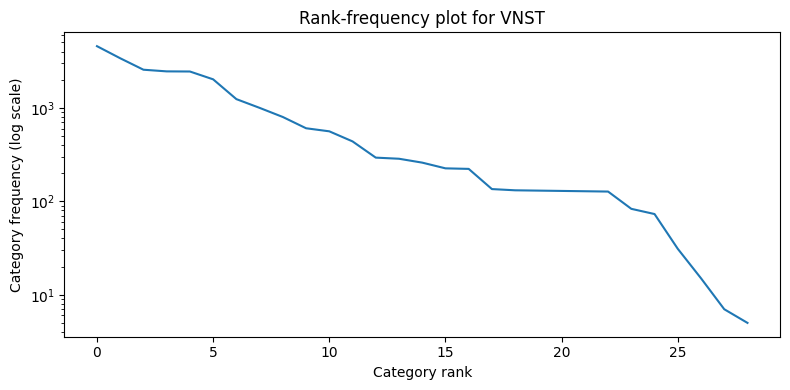

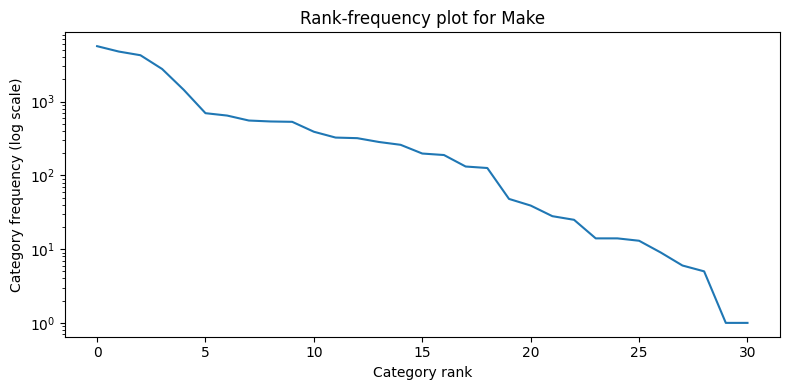

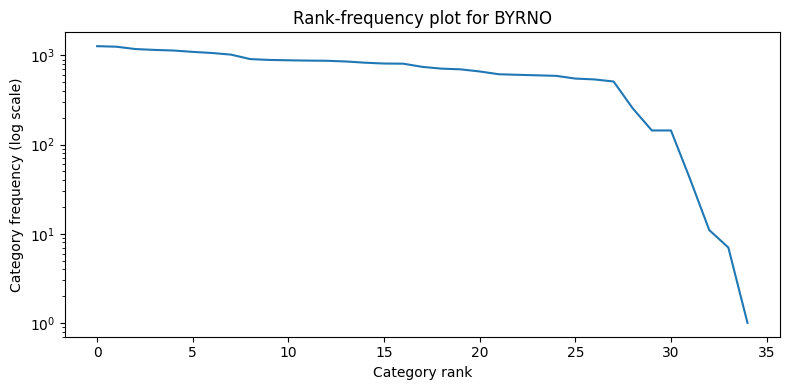

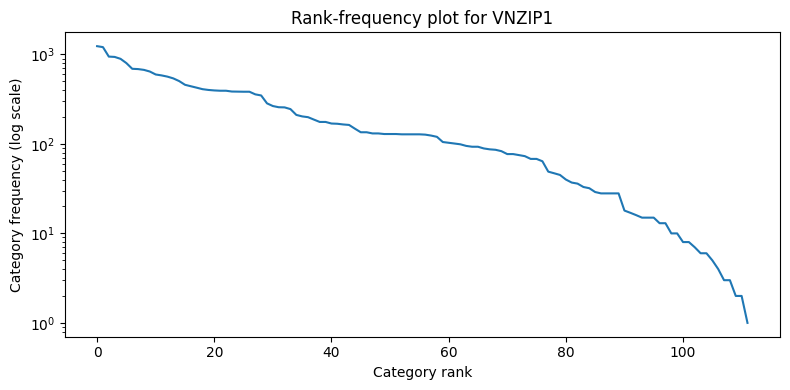

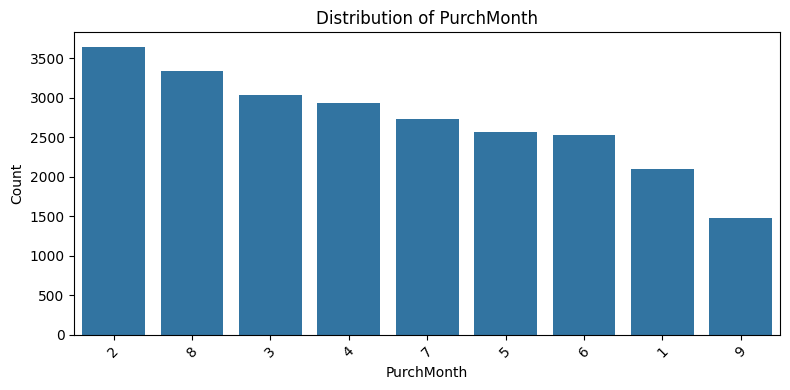

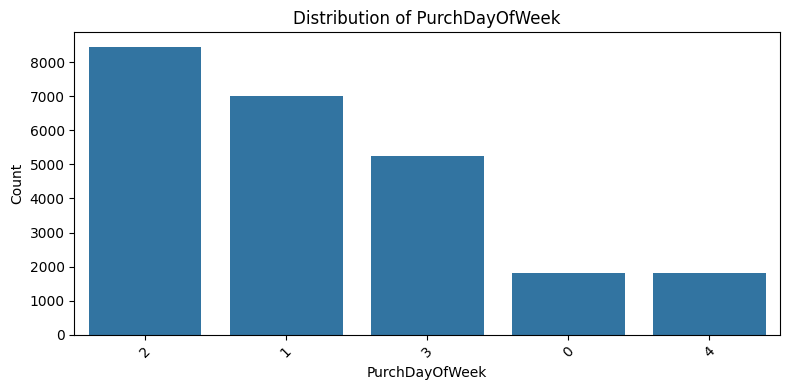

In [30]:
for col in cat_features:
    vc = train[col].value_counts(dropna=False)

    plt.figure(figsize=(8, 4))

    if vc.shape[0] <= 20:
        sns.barplot(x=vc.index.astype(str), y=vc.values)
        plt.xticks(rotation=45)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Distribution of {col}")
    else:
        sns.lineplot(x=range(len(vc)), y=vc.values)
        plt.yscale("log")
        plt.xlabel("Category rank")
        plt.ylabel("Category frequency (log scale)")
        plt.title(f"Rank-frequency plot for {col}")

    plt.tight_layout()
    plt.show()

Посмотрим еще раз на кол-во уникальных

In [31]:
for col in cat_features:
    print(col, train[col].nunique(dropna=False))

Trim 21
Transmission 3
TopThreeAmericanName 4
SubModel 340
Size 12
Model 51
Nationality 4
Color 17
WheelType 4
Auction 3
VNST 29
Make 31
BYRNO 35
VNZIP1 112
PurchMonth 9
PurchDayOfWeek 5


In [32]:
train[cat_features].nunique(dropna=False).sum()

np.int64(680)

Encoding

In [33]:

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_cat = ohe.fit_transform(train[cat_features])
val_cat = ohe.transform(val[cat_features])
test_cat = ohe.transform(test[cat_features])


cat_names = ohe.get_feature_names_out(cat_features)

train_cat = pd.DataFrame(train_cat, columns=cat_names, index=train.index)
val_cat = pd.DataFrame(val_cat, columns=cat_names, index=val.index)
test_cat = pd.DataFrame(test_cat, columns=cat_names, index=test.index)

In [34]:
train_cat.shape

(24327, 680)

In [35]:
train_cat.head(2)

,Trim_Bas,Trim_Cla,Trim_EX,Trim_GLS,Trim_GT,Trim_LS,Trim_LT,Trim_LX,Trim_Lar,Trim_Lim,Trim_Other,Trim_SE,Trim_SEL,Trim_SES,Trim_SLT,Trim_ST,Trim_SXT,Trim_Spo,Trim_Tou,Trim_XLS,Trim_XLT,Transmission_AUTO,Transmission_MANUAL,Transmission_nan,TopThreeAmericanName_CHRYSLER,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER,SubModel_2D CONVERTIBLE,SubModel_2D CONVERTIBLE GTC,SubModel_2D CONVERTIBLE LX,SubModel_2D CONVERTIBLE TOURING,SubModel_2D COUPE,SubModel_2D COUPE EX AUTO,SubModel_2D COUPE GL,SubModel_2D COUPE GL2,SubModel_2D COUPE GLS,SubModel_2D COUPE GS,SubModel_2D COUPE GT,SubModel_2D COUPE LIMTED,SubModel_2D COUPE LS,SubModel_2D COUPE LT,SubModel_2D COUPE LX AUTO,SubModel_2D COUPE LXI,SubModel_2D COUPE R/T,SubModel_2D COUPE SE,SubModel_2D COUPE SS,SubModel_2D COUPE ZX2,SubModel_2D COUPE ZX3,SubModel_2D EXT CAB 3.0L EDGE,SubModel_2D HATCHBACK,SubModel_2D QUAD COUPE LEVEL 2,SubModel_2D QUAD COUPE LEVEL 3,SubModel_2D SUV 4.0L SPORT,SubModel_2D SUV 4.0L SPORT XLS,SubModel_3D COUPE SC1,SubModel_3D COUPE SC2,SubModel_4D CUV,SubModel_4D CUV 2.2L,SubModel_4D CUV 2.3L XLS,SubModel_4D CUV 2.3L XLT,SubModel_4D CUV 2.7L,SubModel_4D CUV 2.7L GLS,SubModel_4D CUV 3.0L,SubModel_4D CUV 3.0L LIMITED,SubModel_4D CUV 3.0L SE,SubModel_4D CUV 3.0L SEL,SubModel_4D CUV 3.0L XLS,SubModel_4D CUV 3.0L XLT,SubModel_4D CUV 3.5L GLS,SubModel_4D CUV DLX,SubModel_4D CUV GLS,SubModel_4D EXT CAB 4.0L EDGE,SubModel_4D MINIVAN 3.4L,SubModel_4D MINIVAN 3.4L VALUE,SubModel_4D MINIVAN EXT 3.4L,SubModel_4D MINIVAN EXT 3.5L,SubModel_4D PASSENGER 3.8L SE,SubModel_4D PASSENGER 3.8L SEL,SubModel_4D PASSENGER 3.9L SES,SubModel_4D SEDAN,SubModel_4D SEDAN 1.8,SubModel_4D SEDAN 1.8S,SubModel_4D SEDAN 2.5 S,SubModel_4D SEDAN 2.7L,SubModel_4D SEDAN 2.7L SE,SubModel_4D SEDAN 3.5L,SubModel_4D SEDAN 3.5L SE,SubModel_4D SEDAN CE,SubModel_4D SEDAN CLASSIC,SubModel_4D SEDAN CUSTOM,SubModel_4D SEDAN CX,SubModel_4D SEDAN CXL,SubModel_4D SEDAN DE,SubModel_4D SEDAN DX,SubModel_4D SEDAN ES,SubModel_4D SEDAN EX,SubModel_4D SEDAN EX AUTO,SubModel_4D SEDAN EXECUTIVE,SubModel_4D SEDAN GL,SubModel_4D SEDAN GL1,SubModel_4D SEDAN GL2,SubModel_4D SEDAN GLS,SubModel_4D SEDAN GS,SubModel_4D SEDAN GT,SubModel_4D SEDAN GT2,SubModel_4D SEDAN GTP,SubModel_4D SEDAN GXE,SubModel_4D SEDAN I,SubModel_4D SEDAN L200,SubModel_4D SEDAN L300,SubModel_4D SEDAN LE,SubModel_4D SEDAN LEVEL 1,SubModel_4D SEDAN LEVEL 2,SubModel_4D SEDAN LEVEL 3,SubModel_4D SEDAN LIMITED,SubModel_4D SEDAN LIMITED AWD,SubModel_4D SEDAN LS,SubModel_4D SEDAN LS 3.5L FFV,SubModel_4D SEDAN LS PREMIUM,SubModel_4D SEDAN LT,SubModel_4D SEDAN LT 3.5L,SubModel_4D SEDAN LT 3.5L FFV,SubModel_4D SEDAN LT 3.9L,SubModel_4D SEDAN LUXURY,SubModel_4D SEDAN LX,SubModel_4D SEDAN LX 5SP,SubModel_4D SEDAN LX AUTO,SubModel_4D SEDAN LXI,SubModel_4D SEDAN PREMIER,SubModel_4D SEDAN S,SubModel_4D SEDAN SE,SubModel_4D SEDAN SE AWD,SubModel_4D SEDAN SE COMFORT,SubModel_4D SEDAN SE FFV,SubModel_4D SEDAN SE SVG,SubModel_4D SEDAN SE1,SubModel_4D SEDAN SEL,SubModel_4D SEDAN SEL AWD,SubModel_4D SEDAN SEL DURATEC,SubModel_4D SEDAN SEL FFV,SubModel_4D SEDAN SES,SubModel_4D SEDAN SES DURATEC,SubModel_4D SEDAN SL,SubModel_4D SEDAN SL1,SubModel_4D SEDAN SL2,SubModel_4D SEDAN SXT,SubModel_4D SEDAN SXT FFV,SubModel_4D SEDAN TOURING,SubModel_4D SEDAN TOURING TURBO,SubModel_4D SEDAN XE,SubModel_4D SEDAN ZTS,SubModel_4D SEDAN ZX4,SubModel_4D SEDAN ZX4 SE,SubModel_4D SEDAN ZX4 ST,SubModel_4D SPORT,SubModel_4D SPORT TOURER,SubModel_4D SPORT TOURING,SubModel_4D SPORT UTILITY,SubModel_4D SPORT UTILITY 3.5L XLS,SubModel_4D SPORT UTILITY ES,SubModel_4D SPORT UTILITY EX,SubModel_4D SPORT UTILITY I,SubModel_4D SPORT UTILITY LE,SubModel_4D SPORT UTILITY LIMITED,SubModel_4D SPORT UTILITY LS,SubModel_4D SPORT UTILITY LX,SubModel_4D SPORT UTILITY S,SubModel_4D SPORT UTILITY SE,SubModel_4D SPORT UTILITY SR5,SubModel_4D SPORT UTILITY XE,SubModel_4D SPORT UTILITY XL7,SubModel_4D SPORT UTILITY XLS,SubModel_4D SPORTBACK LS,SubModel_4D SUV,SubModel_4D SUV 2.2L,Sub

In [36]:
val_cat.head(2)

,Trim_Bas,Trim_Cla,Trim_EX,Trim_GLS,Trim_GT,Trim_LS,Trim_LT,Trim_LX,Trim_Lar,Trim_Lim,Trim_Other,Trim_SE,Trim_SEL,Trim_SES,Trim_SLT,Trim_ST,Trim_SXT,Trim_Spo,Trim_Tou,Trim_XLS,Trim_XLT,Transmission_AUTO,Transmission_MANUAL,Transmission_nan,TopThreeAmericanName_CHRYSLER,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER,SubModel_2D CONVERTIBLE,SubModel_2D CONVERTIBLE GTC,SubModel_2D CONVERTIBLE LX,SubModel_2D CONVERTIBLE TOURING,SubModel_2D COUPE,SubModel_2D COUPE EX AUTO,SubModel_2D COUPE GL,SubModel_2D COUPE GL2,SubModel_2D COUPE GLS,SubModel_2D COUPE GS,SubModel_2D COUPE GT,SubModel_2D COUPE LIMTED,SubModel_2D COUPE LS,SubModel_2D COUPE LT,SubModel_2D COUPE LX AUTO,SubModel_2D COUPE LXI,SubModel_2D COUPE R/T,SubModel_2D COUPE SE,SubModel_2D COUPE SS,SubModel_2D COUPE ZX2,SubModel_2D COUPE ZX3,SubModel_2D EXT CAB 3.0L EDGE,SubModel_2D HATCHBACK,SubModel_2D QUAD COUPE LEVEL 2,SubModel_2D QUAD COUPE LEVEL 3,SubModel_2D SUV 4.0L SPORT,SubModel_2D SUV 4.0L SPORT XLS,SubModel_3D COUPE SC1,SubModel_3D COUPE SC2,SubModel_4D CUV,SubModel_4D CUV 2.2L,SubModel_4D CUV 2.3L XLS,SubModel_4D CUV 2.3L XLT,SubModel_4D CUV 2.7L,SubModel_4D CUV 2.7L GLS,SubModel_4D CUV 3.0L,SubModel_4D CUV 3.0L LIMITED,SubModel_4D CUV 3.0L SE,SubModel_4D CUV 3.0L SEL,SubModel_4D CUV 3.0L XLS,SubModel_4D CUV 3.0L XLT,SubModel_4D CUV 3.5L GLS,SubModel_4D CUV DLX,SubModel_4D CUV GLS,SubModel_4D EXT CAB 4.0L EDGE,SubModel_4D MINIVAN 3.4L,SubModel_4D MINIVAN 3.4L VALUE,SubModel_4D MINIVAN EXT 3.4L,SubModel_4D MINIVAN EXT 3.5L,SubModel_4D PASSENGER 3.8L SE,SubModel_4D PASSENGER 3.8L SEL,SubModel_4D PASSENGER 3.9L SES,SubModel_4D SEDAN,SubModel_4D SEDAN 1.8,SubModel_4D SEDAN 1.8S,SubModel_4D SEDAN 2.5 S,SubModel_4D SEDAN 2.7L,SubModel_4D SEDAN 2.7L SE,SubModel_4D SEDAN 3.5L,SubModel_4D SEDAN 3.5L SE,SubModel_4D SEDAN CE,SubModel_4D SEDAN CLASSIC,SubModel_4D SEDAN CUSTOM,SubModel_4D SEDAN CX,SubModel_4D SEDAN CXL,SubModel_4D SEDAN DE,SubModel_4D SEDAN DX,SubModel_4D SEDAN ES,SubModel_4D SEDAN EX,SubModel_4D SEDAN EX AUTO,SubModel_4D SEDAN EXECUTIVE,SubModel_4D SEDAN GL,SubModel_4D SEDAN GL1,SubModel_4D SEDAN GL2,SubModel_4D SEDAN GLS,SubModel_4D SEDAN GS,SubModel_4D SEDAN GT,SubModel_4D SEDAN GT2,SubModel_4D SEDAN GTP,SubModel_4D SEDAN GXE,SubModel_4D SEDAN I,SubModel_4D SEDAN L200,SubModel_4D SEDAN L300,SubModel_4D SEDAN LE,SubModel_4D SEDAN LEVEL 1,SubModel_4D SEDAN LEVEL 2,SubModel_4D SEDAN LEVEL 3,SubModel_4D SEDAN LIMITED,SubModel_4D SEDAN LIMITED AWD,SubModel_4D SEDAN LS,SubModel_4D SEDAN LS 3.5L FFV,SubModel_4D SEDAN LS PREMIUM,SubModel_4D SEDAN LT,SubModel_4D SEDAN LT 3.5L,SubModel_4D SEDAN LT 3.5L FFV,SubModel_4D SEDAN LT 3.9L,SubModel_4D SEDAN LUXURY,SubModel_4D SEDAN LX,SubModel_4D SEDAN LX 5SP,SubModel_4D SEDAN LX AUTO,SubModel_4D SEDAN LXI,SubModel_4D SEDAN PREMIER,SubModel_4D SEDAN S,SubModel_4D SEDAN SE,SubModel_4D SEDAN SE AWD,SubModel_4D SEDAN SE COMFORT,SubModel_4D SEDAN SE FFV,SubModel_4D SEDAN SE SVG,SubModel_4D SEDAN SE1,SubModel_4D SEDAN SEL,SubModel_4D SEDAN SEL AWD,SubModel_4D SEDAN SEL DURATEC,SubModel_4D SEDAN SEL FFV,SubModel_4D SEDAN SES,SubModel_4D SEDAN SES DURATEC,SubModel_4D SEDAN SL,SubModel_4D SEDAN SL1,SubModel_4D SEDAN SL2,SubModel_4D SEDAN SXT,SubModel_4D SEDAN SXT FFV,SubModel_4D SEDAN TOURING,SubModel_4D SEDAN TOURING TURBO,SubModel_4D SEDAN XE,SubModel_4D SEDAN ZTS,SubModel_4D SEDAN ZX4,SubModel_4D SEDAN ZX4 SE,SubModel_4D SEDAN ZX4 ST,SubModel_4D SPORT,SubModel_4D SPORT TOURER,SubModel_4D SPORT TOURING,SubModel_4D SPORT UTILITY,SubModel_4D SPORT UTILITY 3.5L XLS,SubModel_4D SPORT UTILITY ES,SubModel_4D SPORT UTILITY EX,SubModel_4D SPORT UTILITY I,SubModel_4D SPORT UTILITY LE,SubModel_4D SPORT UTILITY LIMITED,SubModel_4D SPORT UTILITY LS,SubModel_4D SPORT UTILITY LX,SubModel_4D SPORT UTILITY S,SubModel_4D SPORT UTILITY SE,SubModel_4D SPORT UTILITY SR5,SubModel_4D SPORT UTILITY XE,SubModel_4D SPORT UTILITY XL7,SubModel_4D SPORT UTILITY XLS,SubModel_4D SPORTBACK LS,SubModel_4D SUV,SubModel_4D SUV 2.2L,Sub

In [37]:
test_cat.head(2)

,Trim_Bas,Trim_Cla,Trim_EX,Trim_GLS,Trim_GT,Trim_LS,Trim_LT,Trim_LX,Trim_Lar,Trim_Lim,Trim_Other,Trim_SE,Trim_SEL,Trim_SES,Trim_SLT,Trim_ST,Trim_SXT,Trim_Spo,Trim_Tou,Trim_XLS,Trim_XLT,Transmission_AUTO,Transmission_MANUAL,Transmission_nan,TopThreeAmericanName_CHRYSLER,TopThreeAmericanName_FORD,TopThreeAmericanName_GM,TopThreeAmericanName_OTHER,SubModel_2D CONVERTIBLE,SubModel_2D CONVERTIBLE GTC,SubModel_2D CONVERTIBLE LX,SubModel_2D CONVERTIBLE TOURING,SubModel_2D COUPE,SubModel_2D COUPE EX AUTO,SubModel_2D COUPE GL,SubModel_2D COUPE GL2,SubModel_2D COUPE GLS,SubModel_2D COUPE GS,SubModel_2D COUPE GT,SubModel_2D COUPE LIMTED,SubModel_2D COUPE LS,SubModel_2D COUPE LT,SubModel_2D COUPE LX AUTO,SubModel_2D COUPE LXI,SubModel_2D COUPE R/T,SubModel_2D COUPE SE,SubModel_2D COUPE SS,SubModel_2D COUPE ZX2,SubModel_2D COUPE ZX3,SubModel_2D EXT CAB 3.0L EDGE,SubModel_2D HATCHBACK,SubModel_2D QUAD COUPE LEVEL 2,SubModel_2D QUAD COUPE LEVEL 3,SubModel_2D SUV 4.0L SPORT,SubModel_2D SUV 4.0L SPORT XLS,SubModel_3D COUPE SC1,SubModel_3D COUPE SC2,SubModel_4D CUV,SubModel_4D CUV 2.2L,SubModel_4D CUV 2.3L XLS,SubModel_4D CUV 2.3L XLT,SubModel_4D CUV 2.7L,SubModel_4D CUV 2.7L GLS,SubModel_4D CUV 3.0L,SubModel_4D CUV 3.0L LIMITED,SubModel_4D CUV 3.0L SE,SubModel_4D CUV 3.0L SEL,SubModel_4D CUV 3.0L XLS,SubModel_4D CUV 3.0L XLT,SubModel_4D CUV 3.5L GLS,SubModel_4D CUV DLX,SubModel_4D CUV GLS,SubModel_4D EXT CAB 4.0L EDGE,SubModel_4D MINIVAN 3.4L,SubModel_4D MINIVAN 3.4L VALUE,SubModel_4D MINIVAN EXT 3.4L,SubModel_4D MINIVAN EXT 3.5L,SubModel_4D PASSENGER 3.8L SE,SubModel_4D PASSENGER 3.8L SEL,SubModel_4D PASSENGER 3.9L SES,SubModel_4D SEDAN,SubModel_4D SEDAN 1.8,SubModel_4D SEDAN 1.8S,SubModel_4D SEDAN 2.5 S,SubModel_4D SEDAN 2.7L,SubModel_4D SEDAN 2.7L SE,SubModel_4D SEDAN 3.5L,SubModel_4D SEDAN 3.5L SE,SubModel_4D SEDAN CE,SubModel_4D SEDAN CLASSIC,SubModel_4D SEDAN CUSTOM,SubModel_4D SEDAN CX,SubModel_4D SEDAN CXL,SubModel_4D SEDAN DE,SubModel_4D SEDAN DX,SubModel_4D SEDAN ES,SubModel_4D SEDAN EX,SubModel_4D SEDAN EX AUTO,SubModel_4D SEDAN EXECUTIVE,SubModel_4D SEDAN GL,SubModel_4D SEDAN GL1,SubModel_4D SEDAN GL2,SubModel_4D SEDAN GLS,SubModel_4D SEDAN GS,SubModel_4D SEDAN GT,SubModel_4D SEDAN GT2,SubModel_4D SEDAN GTP,SubModel_4D SEDAN GXE,SubModel_4D SEDAN I,SubModel_4D SEDAN L200,SubModel_4D SEDAN L300,SubModel_4D SEDAN LE,SubModel_4D SEDAN LEVEL 1,SubModel_4D SEDAN LEVEL 2,SubModel_4D SEDAN LEVEL 3,SubModel_4D SEDAN LIMITED,SubModel_4D SEDAN LIMITED AWD,SubModel_4D SEDAN LS,SubModel_4D SEDAN LS 3.5L FFV,SubModel_4D SEDAN LS PREMIUM,SubModel_4D SEDAN LT,SubModel_4D SEDAN LT 3.5L,SubModel_4D SEDAN LT 3.5L FFV,SubModel_4D SEDAN LT 3.9L,SubModel_4D SEDAN LUXURY,SubModel_4D SEDAN LX,SubModel_4D SEDAN LX 5SP,SubModel_4D SEDAN LX AUTO,SubModel_4D SEDAN LXI,SubModel_4D SEDAN PREMIER,SubModel_4D SEDAN S,SubModel_4D SEDAN SE,SubModel_4D SEDAN SE AWD,SubModel_4D SEDAN SE COMFORT,SubModel_4D SEDAN SE FFV,SubModel_4D SEDAN SE SVG,SubModel_4D SEDAN SE1,SubModel_4D SEDAN SEL,SubModel_4D SEDAN SEL AWD,SubModel_4D SEDAN SEL DURATEC,SubModel_4D SEDAN SEL FFV,SubModel_4D SEDAN SES,SubModel_4D SEDAN SES DURATEC,SubModel_4D SEDAN SL,SubModel_4D SEDAN SL1,SubModel_4D SEDAN SL2,SubModel_4D SEDAN SXT,SubModel_4D SEDAN SXT FFV,SubModel_4D SEDAN TOURING,SubModel_4D SEDAN TOURING TURBO,SubModel_4D SEDAN XE,SubModel_4D SEDAN ZTS,SubModel_4D SEDAN ZX4,SubModel_4D SEDAN ZX4 SE,SubModel_4D SEDAN ZX4 ST,SubModel_4D SPORT,SubModel_4D SPORT TOURER,SubModel_4D SPORT TOURING,SubModel_4D SPORT UTILITY,SubModel_4D SPORT UTILITY 3.5L XLS,SubModel_4D SPORT UTILITY ES,SubModel_4D SPORT UTILITY EX,SubModel_4D SPORT UTILITY I,SubModel_4D SPORT UTILITY LE,SubModel_4D SPORT UTILITY LIMITED,SubModel_4D SPORT UTILITY LS,SubModel_4D SPORT UTILITY LX,SubModel_4D SPORT UTILITY S,SubModel_4D SPORT UTILITY SE,SubModel_4D SPORT UTILITY SR5,SubModel_4D SPORT UTILITY XE,SubModel_4D SPORT UTILITY XL7,SubModel_4D SPORT UTILITY XLS,SubModel_4D SPORTBACK LS,SubModel_4D SUV,SubModel_4D SUV 2.2L,Sub

In [38]:
Nan_features = train.isna().sum()[train.isna().sum() > 0].sort_values(ascending=False)
Nan_features

WheelTypeID                          925
WheelType                            925
MMRCurrentAuctionAveragePrice        260
MMRCurrentAuctionCleanPrice          260
MMRCurrentRetailAveragePrice         260
MMRCurrentRetailCleanPrice           260
Color                                  8
Transmission                           8
MMRAcquisitionAuctionAveragePrice      3
MMRAcquisitionAuctionCleanPrice        3
MMRAcquisitionRetailAveragePrice       3
MMRAcquisitonRetailCleanPrice          3
dtype: int64

In [39]:
train.WheelTypeID.value_counts(dropna=False)

WheelTypeID
1.0    12545
2.0    10622
NaN      925
3.0      235
Name: count, dtype: int64

дублирующиеся колонки, одна из них не нужна

In [40]:
train.WheelType.value_counts(dropna=False)

WheelType
Alloy      12545
Covers     10622
NaN          925
Special      235
Name: count, dtype: int64

## Num_features

In [41]:
drop_list = ['RefId', 'WheelTypeID', 'IsOnlineSale']
for ft in drop_list:
    num_features.remove(ft)
num_features

['VehYear',
 'VehicleAge',
 'VehOdo',
 'MMRAcquisitionAuctionAveragePrice',
 'MMRAcquisitionAuctionCleanPrice',
 'MMRAcquisitionRetailAveragePrice',
 'MMRAcquisitonRetailCleanPrice',
 'MMRCurrentAuctionAveragePrice',
 'MMRCurrentAuctionCleanPrice',
 'MMRCurrentRetailAveragePrice',
 'MMRCurrentRetailCleanPrice',
 'VehBCost',
 'WarrantyCost']

In [42]:
train[num_features].isna().sum()

VehYear                                0
VehicleAge                             0
VehOdo                                 0
MMRAcquisitionAuctionAveragePrice      3
MMRAcquisitionAuctionCleanPrice        3
MMRAcquisitionRetailAveragePrice       3
MMRAcquisitonRetailCleanPrice          3
MMRCurrentAuctionAveragePrice        260
MMRCurrentAuctionCleanPrice          260
MMRCurrentRetailAveragePrice         260
MMRCurrentRetailCleanPrice           260
VehBCost                               0
WarrantyCost                           0
dtype: int64

In [43]:
for col in num_features:
    med = train[col].median()
    train[col] = train[col].fillna(med)
    val[col] = val[col].fillna(med)
    test[col] = test[col].fillna(med)

In [44]:
train[num_features].describe().T

,count,mean,std,min,25%,50%,75%,max
VehYear,24327.0,2004.823817,1.603392,2001.0,2004.0,2005.0,2006.0,2008.0
VehicleAge,24327.0,4.176224,1.603452,1.0,3.0,4.0,5.0,8.0
VehOdo,24327.0,69842.535372,14288.747223,5368.0,60381.0,71641.0,80499.0,107091.0
MMRAcquisitionAuctionAveragePrice,24327.0,5797.092819,2493.923761,0.0,3944.0,5515.0,7499.0,33543.0
MMRAcquisitionAuctionCleanPrice,24327.0,7028.306820,2784.148711,0.0,4995.0,6654.0,8770.0,36701.0
MMRAcquisitionRetailAveragePrice,24327.0,6753.714679,2710.792300,0.0,4760.0,6456.0,8599.0,36726.0
MMRAcquisitonRetailCleanPrice,24327.0,8083.458215,3025.590439,0.0,5895.5,7686.0,9972.0,40137.0
MMRCurrentAuctionAveragePrice,24327.0,5840.160603,2487.776641,0.0,3998.0,5578.0,7499.0,33369.0
MMRCurrentAuctionCleanPrice,24327.0,7085.299174,2777.462805,0.0,5093.0,6773.0,8814.0,36478.0
MMRCurrentRetailAveragePrice,24327.0,6932.014634,2796.893238,0.0,4884.0,6610.0,8756.0,36539.0


scaler

In [45]:
scaler = StandardScaler()

train_num = scaler.fit_transform(train[num_features])
val_num = scaler.transform(val[num_features])
test_num = scaler.transform(test[num_features])

train_num = pd.DataFrame(train_num, columns=num_features, index=train.index)
val_num = pd.DataFrame(val_num, columns=num_features, index=val.index)
test_num = pd.DataFrame(test_num, columns=num_features, index=test.index)

train_num.describe().T

,count,mean,std,min,25%,50%,75%,max
VehYear,24327.0,-6.666899e-14,1.000021,-2.384879,-0.513807,0.109884,0.733574,1.980956
VehicleAge,24327.0,-1.869311e-17,1.000021,-1.980908,-0.733573,-0.109905,0.513762,2.384765
VehOdo,24327.0,-1.472083e-16,1.000021,-4.512352,-0.662181,0.125868,0.745810,2.606893
MMRAcquisitionAuctionAveragePrice,24327.0,1.869311e-17,1.000021,-2.324535,-0.743058,-0.113114,0.682436,11.125632
MMRAcquisitionAuctionCleanPrice,24327.0,-3.738623e-17,1.000021,-2.524453,-0.730330,-0.134445,0.625588,10.657945
MMRAcquisitionRetailAveragePrice,24327.0,-1.588915e-16,1.000021,-2.491468,-0.735488,-0.109828,0.680732,11.056879
MMRAcquisitonRetailCleanPrice,24327.0,-2.803967e-17,1.000021,-2.671751,-0.723166,-0.131368,0.624202,10.594362
MMRCurrentAuctionAveragePrice,24327.0,-2.336639e-17,1.000021,-2.347590,-0.740500,-0.105382,0.666810,11.065867
MMRCurrentAuctionCleanPrice,24327.0,1.028121e-16,1.000021,-2.551049,-0.717324,-0.112443,0.622416,10.582790
MMRCurrentRetailAveragePrice,24327.0,-9.346556e-18,1.000021,-2.478520,-0.732261,-0.115135,0.652160,10.585886


In [46]:
train.PurchYear.describe()

count    24327.0
mean      2009.0
std          0.0
min       2009.0
25%       2009.0
50%       2009.0
75%       2009.0
max       2009.0
Name: PurchYear, dtype: float64

In [47]:
X_train = pd.concat([train_num, train_cat], axis=1)
X_val = pd.concat([val_num, val_cat], axis=1)
X_test = pd.concat([test_num, test_cat], axis=1)
y_train, y_val, y_test = train[target], val[target], test[target]

In [48]:
print(X_train.shape, len(y_train))
print(X_val.shape, len(y_val))
print(X_test.shape, len(y_test))

(24327, 693) 24327
(24328, 693) 24328
(24328, 693) 24328


# Models

In [49]:
logreg = LogisticRegression(max_iter=2000)
# gaussian_process_classifier = GaussianProcessClassifier()
knn = KNeighborsClassifier(n_neighbors=12)
# svc = SVC(kernel='rbf')
g_nb = GaussianNB()

models = [logreg, knn, g_nb]


In [50]:
from sklearn.metrics import roc_auc_score, f1_score

for model in models:
    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]

    roc_auc = roc_auc_score(y_val, proba)
    gini = 2 * roc_auc - 1
    f1 = f1_score(y_val, pred)

    print(f"Model: {model}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Gini:    {gini:.4f}")
    print(f"F1:      {f1:.4f}")
    print("-" * 40)

Model: LogisticRegression(max_iter=2000)
ROC-AUC: 0.6922
Gini:    0.3844
F1:      0.2346
----------------------------------------
Model: KNeighborsClassifier(n_neighbors=12)
ROC-AUC: 0.6429
Gini:    0.2858
F1:      0.0181
----------------------------------------
Model: GaussianNB()
ROC-AUC: 0.5198
Gini:    0.0396
F1:      0.2356
----------------------------------------


In [51]:
mass = np.array([1,0,2,1,5,100,1])
print(mass == 1)

[ True False False  True False False  True]


In [52]:
from itertools import product
class my_scores:
    def __init__(self):
           pass
    
    def roc_auc(self, y_true, proba):
        y_true = np.array(y_true)
        proba = np.array(proba)

        pos = proba[y_true == 1]
        neg = proba[y_true == 0]

        summ = 0

        for p, n in product(pos, neg):
            if p>n:
                summ+=1
            elif p==n:
                summ+=0.5
        N = (len(pos)*len(neg))
        if N == 0:
            raise ValueError("ТиШо, у тебя 1 из классов 0..")
        
        roc_auc = summ / N
        return roc_auc
                          

    def gini(self, y_true, proba):
            return 2*self.roc_auc(y_true, proba) - 1
    
my_score = my_scores()

In [53]:
proba = logreg.predict_proba(X_val)[:, 1]
print(f"my - roc_auc:{my_score.roc_auc(y_val, proba)} gini:{my_score.gini(y_val, proba)}")
print(f"sk - roc_auc:{roc_auc_score(y_val, proba)} gini:{abs(2*roc_auc_score(y_val, proba) - 1)}")

my - roc_auc:0.6922194344760716 gini:0.3844388689521432
sk - roc_auc:0.6922194344760716 gini:0.3844388689521432


In [54]:
from sklearn.metrics import accuracy_score, recall_score

In [55]:
# train
pred, proba = logreg.predict(X_train), logreg.predict_proba(X_train)[:, 1]
print(
    f"sk - roc_auc:{roc_auc_score(y_train, proba)}\n"
    f"gini:{abs(2 * roc_auc_score(y_train, proba) - 1)}\n"
    f"accuracy:{accuracy_score(y_train, pred)}\n"
    f"recall:{recall_score(y_train, pred)}"
)

sk - roc_auc:0.8004355386536774
gini:0.6008710773073549
accuracy:0.9051259916964689
recall:0.23693629205440228


In [56]:
# val
pred, proba = logreg.predict(X_val), logreg.predict_proba(X_val)[:, 1]
print(
    f"sk - roc_auc:{roc_auc_score(y_val, proba)}\n"
    f"gini:{abs(2 * roc_auc_score(y_val, proba) - 1)}\n"
    f"accuracy:{accuracy_score(y_val, pred)}\n"
    f"recall:{recall_score(y_val, pred)}"
)

sk - roc_auc:0.6922194344760716
gini:0.3844388689521432
accuracy:0.8776718184807629
recall:0.14412136536030343


In [57]:
# test
pred, proba = logreg.predict(X_test), logreg.predict_proba(X_test)[:, 1]
print(
    f"sk - roc_auc:{roc_auc_score(y_test, proba)}\n"
    f"gini:{abs(2 * roc_auc_score(y_test, proba) - 1)}\n"
    f"accuracy:{accuracy_score(y_test, pred)}\n"
    f"recall:{recall_score(y_test, pred)}"
)

sk - roc_auc:0.7313113497957974
gini:0.46262269959159474
accuracy:0.8899210785925682
recall:0.1242544731610338


In [58]:
pd.Series(logreg.coef_[0], index=X_train.columns).sort_values(key=np.abs, ascending=False)

VNZIP1_85018                         -2.673949
WheelType_nan                         2.459631
SubModel_2D COUPE SS                 -1.550139
VNZIP1_37421                         -1.388864
SubModel_4D SEDAN SE COMFORT         -1.318239
Color_nan                            -1.307569
Transmission_nan                     -1.307569
SubModel_4D SEDAN 3.5L                1.225385
SubModel_REG CAB 3.9L                 1.215612
BYRNO_16369                          -1.199273
WheelType_Covers                     -1.198042
SubModel_REG CAB 4.2L STX             1.185242
SubModel_MINIVAN 3.3L SPORT          -1.183631
Make_MINI                             1.183081
WheelType_Alloy                      -1.146336
SubModel_4D SEDAN SEL FFV             1.145731
SubModel_2D COUPE LIMTED              1.133641
SubModel_2D COUPE ZX2                 1.121029
SubModel_PASSENGER 3.4L VALUE         1.119446
SubModel_4D SUV 3.7L                  1.106485
SubModel_4D CUV                      -1.075140
SubModel_MINI

# Models Implementation

In [59]:
class my_models:
    class LogReg:

        def __init__(self, threshold = 0.5,  lr = 0.01, iterations = 100, batch_size = 512):
            self.weights_ = None
            self.bias_ = 0
            self.lr = lr
            self.iterations = iterations
            self.batch_size = batch_size
            self.rng = np.random.default_rng(42)
            self.threshold = threshold

        def fit(self, X, y):
                X = np.asarray(X)
                y = np.asarray(y)
                l, f = X.shape

                w = np.zeros(f)
                b, lr = self.bias_, self.lr

                for i in range(self.iterations):
                    for X_batch, y_batch in self.generate_batches(X, y):
                        func = self.sigmoid(X_batch @ w + b)
                        error = func - y_batch
                        desc_w = (X_batch.T @ error) / len(y_batch)
                        desc_b = error.mean()
                        w = w - lr * desc_w
                        b = b - lr * desc_b
                    
                self.weights_, self.bias_ = w,b
                return self
        
        def predict_proba(self, X):
            X = np.asarray(X)
            prob = self.sigmoid(X @ self.weights_ + self.bias_)
            return prob

        def predict(self, X):
            proba = self.predict_proba(X)
            pred = proba>=self.threshold
            return pred.astype(int)

        def generate_batches(self, X : np.array, y : np.array):
            assert len(X) == len(y)

            batch_size = self.batch_size

            idx = np.arange(len(X))
            self.rng.shuffle(idx)

            for batch_start in range(0, len(X), batch_size):
                batch_idx = idx[batch_start:batch_start+batch_size]
                yield X[batch_idx], y[batch_idx]
        def sigmoid(self, x):
            return 1 / (1 + np.exp(-x))
        


    class KNN:
        def __init__(self, k: int = 5):
            self.k = k
            self.X_train = None
            self.y_train = None

        def fit(self, X, y):
            self.X_train = np.asarray(X)
            self.y_train = np.asarray(y)
            return self

        def predict(self, X):
            X = np.asarray(X)
            preds = []

            for x in X:
                distance = np.sqrt(((self.X_train - x) ** 2).sum(axis=1))
                near_k_idx = np.argsort(distance)[:self.k]
                classes = self.y_train[near_k_idx]

                values, counts = np.unique(classes, return_counts=True)
                pred = values[np.argmax(counts)]
                preds.append(pred)

            return np.array(preds)
        
        def predict_proba(self, X):
            X = np.asarray(X)
            proba = []

            for x in X:
                distance = np.sqrt(((self.X_train - x) ** 2).sum(axis=1))
                near_k_idx = np.argsort(distance)[:self.k]
                classes = self.y_train[near_k_idx]

                prob = np.sum(classes == 1) / self.k
                proba.append(prob)

            return np.array(proba)
        
        
    class GaussNB:

        def __init__(self):
            self.stats = None

        def fit(self, X_train, y_train):
            X = np.array(X_train)
            y = np.array(y_train)
            classes, counts = np.unique(y, return_counts=True)

            means = []
            varbs = []
            freqs = []

            for cl, count in zip(classes, counts):
                X_cl = X[y == cl]
                means.append(X_cl.mean(axis=0))
                varbs.append(X_cl.var(axis=0) + 1e-9)
                freqs.append(count / len(y))

            self.stats = dict(zip(classes, zip(means, varbs, freqs)))
            self.classes_ = classes
            return self
        
        def predict_proba(self, X_test):
            X = np.array(X_test)
            probas = []

            # for x in X:
            #     scores = []

            #     for cl in self.stats:
            #         mean = self.stats[cl][0]
            #         var = self.stats[cl][1]
            #         prior = self.stats[cl][2]

            #         gauss = (1 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mean) ** 2) / (2 * var))
            #         score = np.prod(gauss) * prior
            #         scores.append(score)

            #     scores = np.array(scores)
            #     probas.append(scores / scores.sum())


            for x in X:
                log_scores = []

                for cl in self.classes_:
                    mean, var, prior = self.stats[cl]

                    log_gauss = -0.5 * np.log(2 * np.pi * var) - ((x - mean) ** 2) / (2 * var)
                    log_score = np.sum(log_gauss) + np.log(prior)
                    log_scores.append(log_score)

                log_scores = np.array(log_scores)

                log_scores = log_scores - np.max(log_scores)

                scores = np.exp(log_scores)
                proba = scores / scores.sum()
                probas.append(proba)


            return np.array(probas)
        
        def predict(self, X_test):
            probas = self.predict_proba(X_test)
            # classes = np.array(list(self.stats.keys()))
            # return classes[np.argmax(probas, axis=1)]
            return self.classes_[np.argmax(probas, axis=1)]

## LogReg check

In [60]:
logreg = LogisticRegression(C=np.inf, max_iter=3000, random_state=42)
logreg.fit(X_train, y_train)
sk_pred = logreg.predict(X_val)
sk_proba = logreg.predict_proba(X_val)[:, 1]

/Users/boriskov/Documents/Sch21/Classic ML from scratch/ML4_Classification_problems.ID_1254802-1/ml4.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


In [61]:
# my_logreg = my_models.LogReg()
# my_logreg.fit(X_train, y_train)

# # my_pred = my_logreg.predict(X_val)
# my_proba = my_logreg.predict_proba(X_val)

# print(f"sk - roc_auc:{my_score.roc_auc(y_val, sk_proba)} gini:{my_score.gini(y_val, sk_proba)}")
# print(f"my - roc_auc:{my_score.roc_auc(y_val, my_proba)} gini:{my_score.gini(y_val, my_proba)}")

sk - roc_auc:0.7068974701765941 gini:0.4137949403531882  
my - roc_auc:0.737527253186652 gini:0.47505450637330404  
выполняется 18.2s

In [62]:
from sklearn.linear_model import SGDClassifier
logreg = SGDClassifier(loss="log_loss", penalty=None, max_iter=100, random_state=42)
logreg.fit(X_train, y_train)
# sk_pred = logreg.predict(X_val)
sk_proba = logreg.predict_proba(X_val)[:, 1]
print(f"sk - roc_auc:{my_score.roc_auc(y_val, sk_proba)} gini:{my_score.gini(y_val, sk_proba)}")

sk - roc_auc:0.6892199823615753 gini:0.37843996472315067


## KNN_check

In [63]:
knn = KNeighborsClassifier(n_neighbors= 5)
knn.fit(X_train, y_train)
sk_proba = knn.predict_proba(X_val)[:, 1]
print(f"sk - roc_auc:{my_score.roc_auc(y_val, sk_proba)} gini:{my_score.gini(y_val, sk_proba)}")

sk - roc_auc:0.5985736638391506 gini:0.19714732767830112


In [64]:
# my_knn = my_models.KNN()
# my_knn.fit(X_train, y_train)
# my_proba = my_knn.predict_proba(X_val)
# print(f"my - roc_auc:{my_score.roc_auc(y_val, my_proba)} gini:{my_score.gini(y_val, my_proba)}")

sk - roc_auc:0.5983662781639585 gini:0.19673255632791697  
учится 4m 24.5s

## Gauss check

In [65]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
sk_proba = gnb.predict_proba(X_val)[:, 1]
print(f"sk - roc_auc:{my_score.roc_auc(y_val, sk_proba)} gini:{my_score.gini(y_val, sk_proba)}")

sk - roc_auc:0.5197940587874216 gini:0.03958811757484315


In [66]:
my_gnb = my_models.GaussNB()
my_gnb.fit(X_train, y_train)
my_proba = my_gnb.predict_proba(X_val)[:, 1]
print(f"my - roc_auc:{my_score.roc_auc(y_val, my_proba)} gini:{my_score.gini(y_val, my_proba)}")

my - roc_auc:0.5199964096534893 gini:0.03999281930697851


гаусс у менч не работает, в связи с тем что у меня очень большое кол-во фич созданных через OneHotEncoder, то есть бинарныз, а он нормально работает на числовых фичах

# Feature generation and selection

In [67]:
X_train[num_features].columns

Index(['VehYear', 'VehicleAge', 'VehOdo', 'MMRAcquisitionAuctionAveragePrice',
       'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice',
       'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice',
       'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice',
       'MMRCurrentRetailCleanPrice', 'VehBCost', 'WarrantyCost'],
      dtype='str')

In [68]:
train[cat_features].columns

Index(['Trim', 'Transmission', 'TopThreeAmericanName', 'SubModel', 'Size',
       'Model', 'Nationality', 'Color', 'WheelType', 'Auction', 'VNST', 'Make',
       'BYRNO', 'VNZIP1', 'PurchMonth', 'PurchDayOfWeek'],
      dtype='str')

In [69]:
G_train = pd.concat([train_num, train[cat_features]], axis=1)
G_val = pd.concat([val_num, val[cat_features]], axis=1)
G_test = pd.concat([test_num, test[cat_features]], axis=1)

In [70]:

def feature_generation(X : pd.DataFrame):

    # отношения
    eps = 1e-6
    X['cost_to_warranty'] = X['VehBCost'] / (X['WarrantyCost'] + eps)
    X['warranty_to_cost'] = X['WarrantyCost'] / (X['VehBCost'] + eps)

    X['cost_to_age'] = X['VehBCost'] / (X['VehicleAge'] + eps)
    X['odo_to_age'] = X['VehOdo'] / (X['VehicleAge'] + eps)

    X['cost_to_odo'] = X['VehBCost'] / (X['VehOdo'] + eps)
    X['warranty_to_age'] = X['WarrantyCost'] / (X['VehicleAge'] + eps)

    # groupby

    X['BYRNO_VehBCost_mean'] = X.groupby('BYRNO')['VehBCost'].transform('mean')
    X['BYRNO_VehOdo_mean'] = X.groupby('BYRNO')['VehOdo'].transform('mean')

    X['VNZIP1_VehBCost_mean'] = X.groupby('VNZIP1')['VehBCost'].transform('mean')
    X['VNZIP1_VehOdo_mean'] = X.groupby('VNZIP1')['VehOdo'].transform('mean')

    X['PurchMonth_VehBCost_mean'] = X.groupby('PurchMonth')['VehBCost'].transform('mean')
    X['PurchMonth_VehOdo_mean'] = X.groupby('PurchMonth')['VehOdo'].transform('mean')

    X['SubModel_VehBCost_mean'] = X.groupby('SubModel')['VehBCost'].transform('mean')
    X['SubModel_VehOdo_mean'] = X.groupby('SubModel')['VehOdo'].transform('mean')

    X['Trim_VehBCost_mean'] = X.groupby('Trim')['VehBCost'].transform('mean')
    X['Trim_VehOdo_mean'] = X.groupby('Trim')['VehOdo'].transform('mean')

    X['Make_VehBCost_mean'] = X.groupby('Make')['VehBCost'].transform('mean')
    X['Make_VehOdo_mean'] = X.groupby('Make')['VehOdo'].transform('mean')

    # Частоты

    X['Nationality_freq'] = X['Nationality'].map(X['Nationality'].value_counts()).fillna(0)
    X['Auction_freq'] = X['Auction'].map(X['Auction'].value_counts())
    X['VNZIP1_freq'] = X['VNZIP1'].map(X['VNZIP1'].value_counts())

    return X

In [71]:
gen_train = feature_generation(G_train)

# gen_train = gen_train.drop(columns=cat_features)
gen_train = pd.concat([gen_train.drop(columns=cat_features), train_cat], axis=1)

gen_val = feature_generation(G_val)

# gen_val = gen_val.drop(columns=cat_features)
gen_val = pd.concat([gen_val.drop(columns=cat_features), val_cat], axis=1)

gen_test = feature_generation(G_test)
# gen_test = gen_test.drop(columns=cat_features)
gen_test = pd.concat([gen_test.drop(columns=cat_features), test_cat], axis=1)
gen_train.shape

(24327, 714)

In [72]:
gen_train['Nationality_freq'].unique()

array([21168,   848,  2281,    30])

In [73]:
gen_test['Nationality_freq'].unique()

array([19641,  1579,  2984,   124])

In [74]:
gen_val.shape

(24328, 714)

In [75]:
gen_test.shape

(24328, 714)

In [76]:
for col in gen_test.columns:
    if gen_test[col].isna().sum() > 0:
        print(col, gen_test[col].isna().sum())

In [77]:
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(gen_train, y_train)

/Users/boriskov/Documents/Sch21/Classic ML from scratch/ML4_Classification_problems.ID_1254802-1/ml4.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [78]:
pred, proba = logreg.predict(gen_train), logreg.predict_proba(gen_train)[:, 1]
print(
    f"sk - roc_auc:{roc_auc_score(y_train, proba)}\n"
    f"gini:{abs(2 * roc_auc_score(y_train, proba) - 1)}\n"
    f"accuracy:{accuracy_score(y_train, pred)}\n"
    f"recall:{recall_score(y_train, pred)}"
)

sk - roc_auc:0.7096999591211917
gini:0.4193999182423833
accuracy:0.8859292144530768
recall:0.02219040801717967


In [79]:
pred, proba = logreg.predict(gen_val), logreg.predict_proba(gen_val)[:, 1]
print(
    f"sk - roc_auc:{roc_auc_score(y_val, proba)}\n"
    f"gini:{abs(2 * roc_auc_score(y_val, proba) - 1)}\n"
    f"accuracy:{accuracy_score(y_val, pred)}\n"
    f"recall:{recall_score(y_val, pred)}"
)

sk - roc_auc:0.6860857839840141
gini:0.3721715679680282
accuracy:0.8711772443275239
recall:0.01643489254108723


In [80]:
pred, proba = logreg.predict(gen_test), logreg.predict_proba(gen_test)[:, 1]
print(
    f"sk - roc_auc:{roc_auc_score(y_test, proba)}\n"
    f"gini:{abs(2 * roc_auc_score(y_test, proba) - 1)}\n"
    f"accuracy:{accuracy_score(y_test, pred)}\n"
    f"recall:{recall_score(y_test, pred)}"
)

sk - roc_auc:0.6977009987626254
gini:0.39540199752525074
accuracy:0.8774251890825386
recall:0.03578528827037773


## Selection

weights

In [81]:
feature_weights = pd.Series(logreg.coef_[0], index=gen_train.columns)

top_100 = feature_weights.abs().sort_values(ascending=False).head(100).index.tolist()

X_train_top = gen_train[top_100]
X_val_top = gen_val[top_100]
X_test_top = gen_test[top_100]

In [82]:
X_train_top.shape

(24327, 100)

In [83]:
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_top, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [84]:
pred, proba = logreg.predict(X_val_top), logreg.predict_proba(X_val_top)[:, 1]
print(
    f"sk - roc_auc:{roc_auc_score(y_val, proba)}\n"
    f"gini:{abs(2 * roc_auc_score(y_val, proba) - 1)}\n"
    f"accuracy:{accuracy_score(y_val, pred)}\n"
    f"recall:{recall_score(y_val, pred)}"
)

sk - roc_auc:0.733427882211068
gini:0.46685576442213605
accuracy:0.8835909240381453
recall:0.20922882427307207


In [85]:
pred, proba = logreg.predict(X_test_top), logreg.predict_proba(X_test_top)[:, 1]
print(
    f"sk - roc_auc:{roc_auc_score(y_test, proba)}\n"
    f"gini:{abs(2 * roc_auc_score(y_test, proba) - 1)}\n"
    f"accuracy:{accuracy_score(y_test, pred)}\n"
    f"recall:{recall_score(y_test, pred)}"
)

sk - roc_auc:0.7395955877436771
gini:0.4791911754873541
accuracy:0.8990874712265702
recall:0.23856858846918488


In [86]:
logreg.coef_

array([[ 2.93602905e+00, -4.72577064e-01, -4.15767655e-01,
        -3.61974098e-01, -2.16539160e-02,  1.25719849e-01,
        -2.97034466e-01, -1.89855661e-01,  1.14495499e-01,
         1.21291732e+00, -2.20962706e-01, -5.74890422e-01,
        -6.37483857e-02, -4.24686262e-01,  2.38982399e-01,
         2.39730728e-01, -2.55800013e-01,  1.12724984e-01,
         3.03873963e-01, -1.82517901e-01,  8.11139850e-02,
        -2.41577930e-01, -8.78760054e-01, -7.27491422e-01,
        -3.12957569e-02, -1.87087493e-01, -3.07965990e-02,
        -1.16805350e-01,  1.36290913e-01, -6.07439516e-02,
        -5.25950836e-02, -2.12316994e-01,  8.72803478e-02,
        -4.04555816e-01, -3.51076639e-01, -6.77527097e-02,
        -1.61339963e-01, -1.48903751e-01, -1.65285967e-01,
        -2.97830590e-01, -2.15315107e-01, -1.50336921e-04,
         7.90289269e-02, -1.52447483e-01, -1.79453714e-02,
        -2.37395987e-01, -9.32172597e-02, -1.28973596e+00,
        -3.73016855e-02, -2.99023707e-01, -1.39558942e-0

In [87]:
top_100

['WheelType_nan',
 'WheelType_Covers',
 'WheelType_Alloy',
 'VehYear',
 'VehicleAge',
 'VehOdo',
 'Auction_OTHER',
 'TopThreeAmericanName_OTHER',
 'WarrantyCost',
 'Transmission_AUTO',
 'VehBCost',
 'Nationality_OTHER ASIAN',
 'Size_MEDIUM',
 'Auction_MANHEIM',
 'TopThreeAmericanName_FORD',
 'BYRNO_VehOdo_mean',
 'Auction_ADESA',
 'Make_VehOdo_mean',
 'PurchMonth_5',
 'Make_FORD',
 'VNST_TX',
 'TopThreeAmericanName_GM',
 'Nationality_TOP LINE ASIAN',
 'BYRNO_99750',
 'Make_CHEVROLET',
 'VNST_FL',
 'Trim_LS',
 'Color_WHITE',
 'Make_KIA',
 'PurchDayOfWeek_3',
 'Trim_Other',
 'PurchDayOfWeek_1',
 'VNST_AZ',
 'VNZIP1_VehOdo_mean',
 'PurchDayOfWeek_4',
 'Trim_VehBCost_mean',
 'Trim_VehOdo_mean',
 'Trim_EX',
 'PurchMonth_6',
 'SubModel_VehOdo_mean',
 'MMRCurrentRetailAveragePrice',
 'Size_LARGE',
 'VNZIP1_75236',
 'PurchMonth_4',
 'Make_DODGE',
 'VNST_SC',
 'Color_BLUE',
 'BYRNO_99761',
 'Color_SILVER',
 'Model_STRATUS V6 2.7L V6 M',
 'Size_VAN',
 'VNZIP1_75050',
 'Make_NISSAN',
 'Transmissi

sklearn

In [88]:
from sklearn.feature_selection import SelectKBest, f_classif

In [89]:
selector = SelectKBest(score_func=f_classif, k = 50)
X_train_select = selector.fit_transform(gen_train, y_train)
X_val_select = selector.transform(gen_val)
X_test_select = selector.transform(gen_test)

In [90]:
selected_features = gen_train.columns[selector.get_support()]
selected_features.tolist()

['VehYear',
 'VehicleAge',
 'VehOdo',
 'MMRAcquisitionAuctionAveragePrice',
 'MMRAcquisitionAuctionCleanPrice',
 'MMRAcquisitionRetailAveragePrice',
 'MMRAcquisitonRetailCleanPrice',
 'MMRCurrentAuctionAveragePrice',
 'MMRCurrentAuctionCleanPrice',
 'MMRCurrentRetailAveragePrice',
 'MMRCurrentRetailCleanPrice',
 'VehBCost',
 'WarrantyCost',
 'BYRNO_VehOdo_mean',
 'VNZIP1_VehBCost_mean',
 'VNZIP1_VehOdo_mean',
 'PurchMonth_VehOdo_mean',
 'SubModel_VehBCost_mean',
 'SubModel_VehOdo_mean',
 'Make_VehOdo_mean',
 'Auction_freq',
 'Trim_SXT',
 'TopThreeAmericanName_CHRYSLER',
 'TopThreeAmericanName_FORD',
 'SubModel_4D SEDAN SXT FFV',
 'SubModel_PASSENGER 3.8L LX',
 'Size_COMPACT',
 'Model_EXPLORER 2WD V6 4.0L',
 'Model_IMPALA 3.5L V6 SFI',
 'Model_Other',
 'Model_PT CRUISER 2.4L I4 M',
 'Model_STRATUS V6 2.7L V6 M',
 'Model_WINDSTAR FWD V6 3.8L',
 'WheelType_Alloy',
 'WheelType_Covers',
 'WheelType_nan',
 'Auction_ADESA',
 'Auction_MANHEIM',
 'VNST_TX',
 'Make_DODGE',
 'Make_FORD',
 'BYRNO_

In [91]:
logreg.fit(X_train_select, y_train)

for name, X, y in [
    ("train", X_train_select, y_train),
    ("val", X_val_select, y_val),
    ("test", X_test_select, y_test),
]:
    pred = logreg.predict(X)
    proba = logreg.predict_proba(X)[:, 1]
    roc_auc = roc_auc_score(y, proba)

    print(
        f"{name}:\n"
        f"roc_auc:{roc_auc}\n"
        f"gini:{abs(2 * roc_auc - 1)}\n"
        f"accuracy:{accuracy_score(y, pred)}\n"
        f"recall:{recall_score(y, pred)}\n"
    )

train:
roc_auc:0.7592464909031936
gini:0.5184929818063873
accuracy:0.9021252106712706
recall:0.2279885468861847

val:
roc_auc:0.7425268913100772
gini:0.4850537826201544
accuracy:0.8801792173627097
recall:0.2266118836915297

test:
roc_auc:0.745053284236393
gini:0.4901065684727861
accuracy:0.8997451496218349
recall:0.23989396951623593



/Users/boriskov/Documents/Sch21/Classic ML from scratch/ML4_Classification_problems.ID_1254802-1/ml4.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [92]:
# from sklearn.feature_selection import RFECV
# from sklearn.model_selection import TimeSeriesSplit

# cv = TimeSeriesSplit(n_splits=5)

# selector = RFECV(
#     estimator=LogisticRegression(max_iter=2000, random_state=42),
#     step=10,
#     cv=cv,
#     scoring='roc_auc',
#     n_jobs=-1
# )

# X_train_sel_cv = selector.fit_transform(gen_train, y_train)
# X_val_sel_cv = selector.transform(gen_val)
# X_test_sel_cv = selector.transform(gen_test)

In [93]:
# logreg.fit(X_train_sel_cv, y_train)

# for name, X, y in [
#     ("train", X_train_sel_cv, y_train),
#     ("val", X_val_sel_cv, y_val),
#     ("test", X_test_sel_cv, y_test),
# ]:
#     pred = logreg.predict(X)
#     proba = logreg.predict_proba(X)[:, 1]
#     roc_auc = roc_auc_score(y, proba)

#     print(
#         f"{name}:\n"
#         f"roc_auc:{roc_auc}\n"
#         f"gini:{abs(2 * roc_auc - 1)}\n"
#         f"accuracy:{accuracy_score(y, pred)}\n"
#         f"recall:{recall_score(y, pred)}\n"
#     )

train:
roc_auc:0.8007634799756834
gini:0.6015269599513668
accuracy:0.9050437785176964
recall:0.23729420186113098

val:
roc_auc:0.7313094994867336
gini:0.46261899897346725
accuracy:0.89522361065439
recall:0.1749502982107356

test:
roc_auc:0.696424748415899
gini:0.39284949683179793
accuracy:0.87865833607366
recall:0.1665613147914033

переобучилось.. 0.39 на тесте. Оставим как лучший набор фич топ 50 после SelectKBest

### hyperparameter optimization

In [94]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    C = trial.suggest_float("C", 1e-4, 100, log=True)
    solver = trial.suggest_categorical("solver", ["lbfgs", "liblinear"])
    max_iter = trial.suggest_int("max_iter", 1000, 5000, step=1000)

    model = LogisticRegression(
        C=C,
        solver=solver,
        max_iter=max_iter,
        random_state=42
    )

    model.fit(X_train_select, y_train)
    proba = model.predict_proba(X_val_select)[:, 1]

    score = roc_auc_score(y_val, proba)
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("best_score:", study.best_value)
print("best_params:", study.best_params)

/Users/boriskov/Documents/Sch21/Classic ML from scratch/ML4_Classification_problems.ID_1254802-1/ml4.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 0. Best value: 0.723053:   4%|▍         | 2/50 [00:00<00:02, 20.00it/s]/Users/boriskov/Documents/Sch21/Classic ML from scratch/ML4_Classification_problems.ID_1254802-1/ml4.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sc

best_score: 0.7436228564547148
best_params: {'C': 0.14038444076242396, 'solver': 'lbfgs', 'max_iter': 1000}


In [95]:
logreg = LogisticRegression(**study.best_params, class_weight = 'balanced')
logreg.fit(X_train_select, y_train)

for name, X, y in [
    ("train", X_train_select, y_train),
    ("val", X_val_select, y_val),
    ("test", X_test_select, y_test),
]:
    pred = logreg.predict(X)
    proba = logreg.predict_proba(X)[:, 1]
    roc_auc = roc_auc_score(y, proba)

    print(
        f"{name}:\n"
        f"roc_auc:{roc_auc}\n"
        f"gini:{abs(2 * roc_auc - 1)}\n"
        f"accuracy:{accuracy_score(y, pred)}\n"
        f"recall:{recall_score(y, pred)}\n"
    )

train:
roc_auc:0.7599263250649458
gini:0.5198526501298917
accuracy:0.7464134500760472
recall:0.6073729420186114

val:
roc_auc:0.744082902268743
gini:0.4881658045374859
accuracy:0.7670174284774746
recall:0.5470922882427307

test:
roc_auc:0.7487352282364004
gini:0.49747045647280075
accuracy:0.733475830318974
recall:0.6060304837640822



/Users/boriskov/Documents/Sch21/Classic ML from scratch/ML4_Classification_problems.ID_1254802-1/ml4.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Metrics implementation

In [96]:
class Metrics:
    def __init__(self):
        pass

    def Recall(self, pred, true):
        tp = np.sum((pred == 1) & (true == 1))
        fn_tp = np.sum(true == 1)
        return tp / fn_tp
    
    def Precision(self, pred, true):
        tp = np.sum((pred == 1) & (true == 1))
        tp_fp = np.sum(pred==1)
        return tp/tp_fp

    def F1(self, pred, true):
        pr = self.Precision(pred, true)
        rec = self.Recall(pred, true)
        return 2*pr*rec/(pr+rec)
    
    def AUC_PR(self, probas, true):
        threholds = np.unique(probas)

        points = []
        for threhold in threholds:
            pred = (probas >= threhold)
            rec = self.Recall(pred, true)
            pr = self.Precision(pred, true)
            points.append((rec, pr))

        points = sorted(points, key=lambda x: x[0])
        auc_pr = 0

        for idx in range(len(points)-1):
            a = points[idx][1]
            b = points[idx+1][1]
            h = points[idx+1][0] - points[idx][0]
            auc_pr += (a+b)*h/2
        return auc_pr

In [97]:
pred = logreg.predict(X_test_select)
proba = logreg.predict_proba(X_test_select)[:, 1]

In [98]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_val, proba)
auc_pr = auc(recall, precision)
auc_pr

0.12660394135517158

In [99]:
Met = Metrics()
auc_pr = Met.AUC_PR(proba, y_val)
auc_pr

np.float64(0.1266039405103305)

тут наверное нелпохо было бы брать полную F1, потому что мы можем взять и кол-вом и качеством